In [1]:
%pip install librosa matplotlib soundfile

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 KB 471.8 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 8.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 9.4 MB/s eta 0:00:00:00:010:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 KB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 9.2 MB/s eta 0:00:0000:01:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.6/407.6 KB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 11.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 13.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.0/24

/home/huangjie/MdiriCode/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


采样率: 16000 Hz
采样点数量: 176800
时长: 11.05 秒


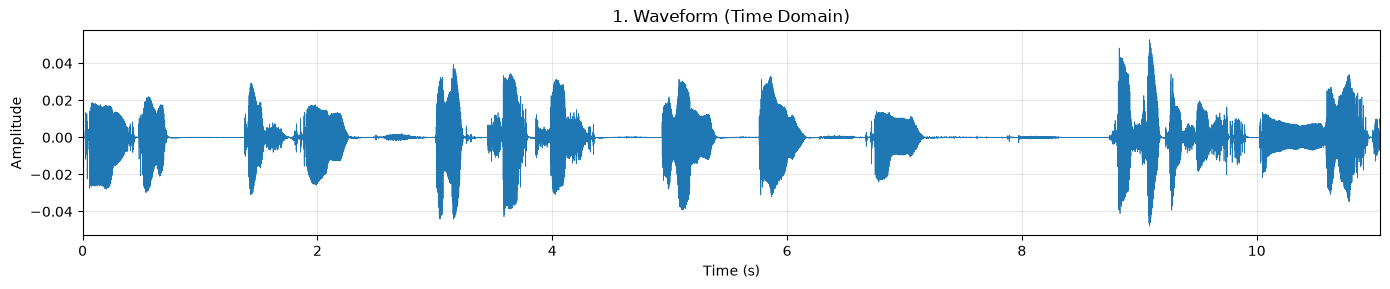

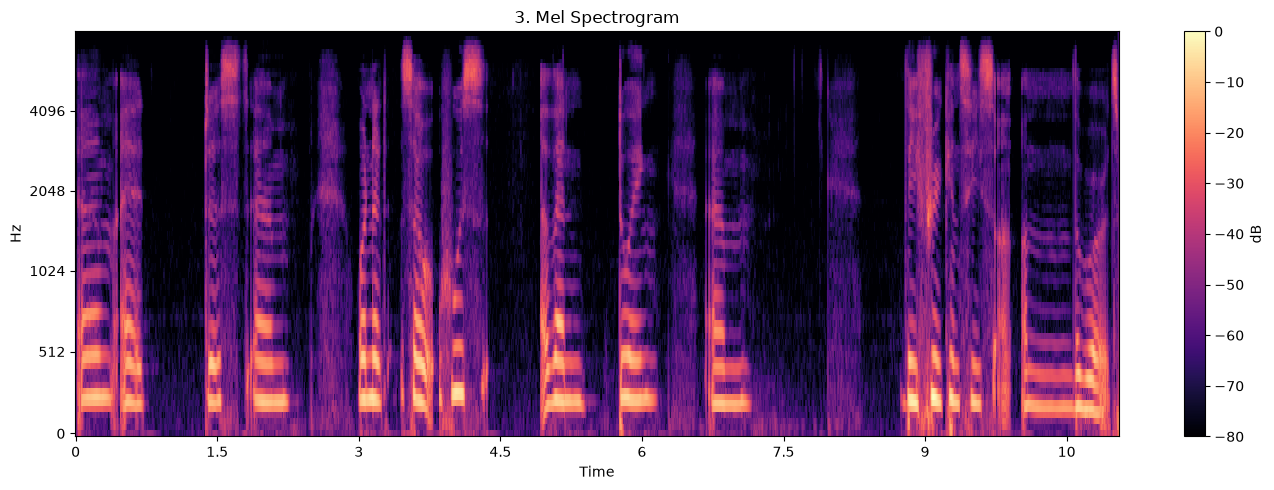

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取音频
# =========================
audio_path = "./audio.wav"
y, sr = librosa.load(audio_path, sr=None, mono=True)

print(f"采样率: {sr} Hz")
print(f"采样点数量: {len(y)}")
print(f"时长: {len(y)/sr:.2f} 秒")

time_axis = np.arange(len(y)) / sr

# =========================
# 2. 原始波形 (Time Domain)
# =========================
plt.figure(figsize=(14, 3))
plt.plot(time_axis, y, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("1. Waveform (Time Domain)")
plt.grid(alpha=0.3)
plt.xlim(0, time_axis[-1])
plt.tight_layout()
plt.show()

# =========================
# 3. 能量包络 (RMS Energy)
# =========================
# frame_length = int(0.025 * sr)
# hop_length   = int(0.010 * sr)

# rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
# energy_db = librosa.amplitude_to_db(rms, ref=np.max)
# rms_times = librosa.frames_to_time(np.arange(len(energy_db)), sr=sr, hop_length=hop_length)

# plt.figure(figsize=(14, 3))
# plt.plot(rms_times, energy_db, linewidth=0.8)
# plt.xlabel("Time (s)")
# plt.ylabel("Energy (dB)")
# plt.title("2. Energy Envelope (RMS → dB)")
# plt.grid(alpha=0.3)
# plt.xlim(0, time_axis[-1])
# plt.tight_layout()
# plt.show()

# =========================
# 4. Mel 频谱 (Frequency × Time)
# =========================
y16k, sr16k = librosa.load(audio_path, sr=16000)

mel = librosa.feature.melspectrogram(
    y=y16k, sr=sr16k,
    n_fft=512,      # FFT 窗口 512 点 (32ms)
    hop_length=160, # 帧移 160 点 (10ms)
    n_mels=80       # 80 个 Mel 滤波器
)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    mel_db, sr=sr16k, hop_length=160,
    x_axis="time", y_axis="mel", cmap="magma"
)
plt.colorbar(label="dB")
plt.title("3. Mel Spectrogram")
plt.tight_layout()
plt.show()

## 图1 — 波形图 (Waveform)

- X 轴 = 时间，Y 轴 = 振幅（空气振动强度）。
- 密集振荡的区域 → 有声音，平坦区域 → 静音。
- 从波形可以直接看出语音的起止位置，这是 VAD（语音端点检测）的基础。

---

## 图2 — 能量包络 (Energy Envelope)

- 将波形分帧（25ms 窗口，10ms 步长），每帧计算 RMS（均方根能量），再转为 dB。
- 相比原始波形更平滑，能清晰看到「哪段时间有声音、哪段是静音」。
- 常用于语音端点检测（VAD）、音频切分、响度分析。

---

## 图3 — Mel 频谱图 (Mel Spectrogram)

- X 轴 = 时间，Y 轴 = Mel 频率（人耳感知的频率刻度，低频分辨更精细），颜色 = 能量 (dB)。
- 它将一维时序信号变成二维「热力图」，同时展示「什么频率在什么时候出现」。

**关键参数：**

| 参数 | 含义 |
|------|------|
| `n_fft=512` | FFT 窗口大小，决定频率分辨率（512/16000=32ms 一帧） |
| `hop_length=160` | 帧移，决定时间分辨率（160/16000=10ms 一帧） |
| `n_mels=80` | Mel 滤波器个数，即 Y 轴的分辨率 |

**怎么读图？**
- 亮色横条 = 某个频率持续有能量（如元音共振峰）。
- 亮色竖条 = 瞬间爆发（如辅音、爆破音）。
- 低频区域通常更亮 → 语音能量集中在低频。
- Mel 频谱是语音识别（ASR）、说话人识别等任务的标配输入。

In [3]:
from fireredvad import FireRedVad, FireRedVadConfig
config = FireRedVadConfig()
vad = FireRedVad.from_pretrained('/home/huangjie/MdiriCode/Big-Yellow-J.github.io/code/Python/AudioSignalProcessing/model_pth/VAD', config)